# Shapers

In [4]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import tdspy as tds
import tdspy.plot as tdsplot
import cvxpy as cp

## Zero-vibration (ZV) shaper


$$
S(s) = A + (1 - A) * e^{(-sT)}
$$

In [5]:
def zv_shaper(s0: complex):
    """ S(s) = A + (1 - A) * exp(-s*T)
    Args:
        c0 (complex): zero to place
    """

    beta, omega = -np.real(s0), np.abs(np.imag(s0))
    T = np.pi / omega
    A = np.exp(np.pi*beta/omega) / (1 + np.exp(np.pi*beta/omega))

    # also equivalent to
    tau_vector = np.array([0.0, T], dtype=np.float64)
    a_vector = np.array([A, 1-A], dtype=np.float64)
    return tau_vector, a_vector


def dazv_shaper(s0: complex, alpha=0.3, T=None):
    """
                    1             exp(-s*alpha*T) - exp(-s*T)
    S(s) =  ----------------- * -------------------------------
             (1 - alpha) * T                  s
    """
    assert alpha >= 0.0 and alpha <= 1.0
    
    beta, omega = -np.real(s0), np.abs(np.imag(s0))
    if T is None:
        T = 0.5 * np.pi / omega
    
    assert T >= 0 and T<= np.pi / omega

    # code logic here
    raise NotImplementedError("...")


def residual_vibrations(s, a_vector, tau_vector):
    pass


In [6]:
s0 = -24*0.1 + 24*np.sqrt(1-0.1**2)*1j
tau_vector, a_vector = zv_shaper(s0=s0)

E = np.zeros(shape=(0,0), dtype=np.float64)
A = np.zeros(shape=(0,0,0), dtype=np.float64)
hA = np.zeros(shape=(0,), dtype=np.float64)

B = np.zeros(shape=(0,2,0), dtype=np.float64)
hB = np.array([], dtype=np.float64)

C = np.zeros(shape=(1,0,0), dtype=np.float64)
hC = np.zeros(shape=(0,), dtype=np.float64)

D = a_vector[np.newaxis, np.newaxis, :]
hD = tau_vector

ddae = tds.DDAE(A, hA, E=E, B=B, hB=hB, C=C, hC=hC, D=D, hD=hD)

In [7]:
zeros, _ = tds.zeros(ddae, r=[-100, 10, 0, 1250])
print(zeros)

[-2.4  +23.87969849j -2.4  +71.63909547j -2.4+1217.86462302j
 -2.4 +119.39849245j -2.4 +167.15788943j -2.4 +214.91728642j
 -2.4+1170.10522604j -2.4 +262.6766834j  -2.4 +310.43608038j
 -2.4+1122.34582906j -2.4 +358.19547736j -2.4 +405.95487434j
 -2.4+1074.58643208j -2.4 +453.71427132j -2.4 +501.4736683j
 -2.4 +549.23306528j -2.4 +596.99246226j -2.4+1026.82703509j
 -2.4 +644.75185925j -2.4 +979.06763811j -2.4 +692.51125623j
 -2.4 +931.30824113j -2.4 +740.27065321j -2.4 +883.54884415j
 -2.4 +788.03005019j -2.4 +835.78944717j]


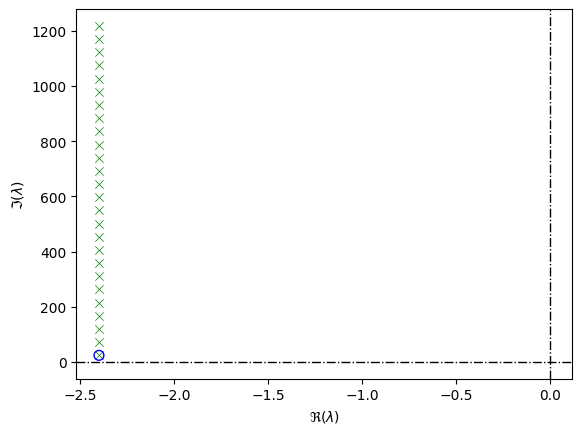

In [8]:
tdsplot.eigen_plot(zeros)
plt.scatter([np.real(s0)], [np.imag(s0)], s=50, facecolors='none', edgecolors='b', marker="o")
#plt.plot([np.real(placed_zero)],[np.imag([placed_zero])], "ro", alpha=0.4)

In [9]:
real_points = np.linspace(-5, 0,  num=100)
imag_points = np.linspace(0, 50, num=100)
real_grid, imag_grid = np.meshgrid(real_points, imag_points)
complex_array = real_grid + imag_grid * 1j

In [10]:
complex_array.shape

(100, 100)

In [11]:
r = np.abs(
    np.sum(
        np.exp(complex_array[:,:,np.newaxis] * tau_vector[np.newaxis,:]) * a_vector,
        axis=-1
    )
)

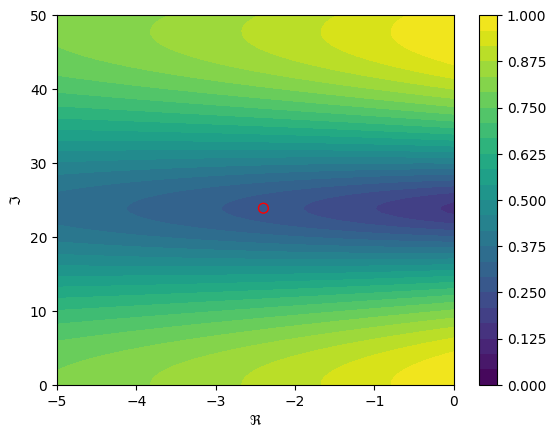

In [12]:
fig, ax = plt.subplots(1,1)
x, y = real_points, imag_points
z = r
c = ax.contourf(x, y, z, levels=np.linspace(0,np.max(z),25))
#fig.suptitle(AA(prefix)+' Input Data Contour Map')
ax.set_xlabel('$\Re$')
ax.set_ylabel('$\Im$')
plt.scatter([np.real(s0)], [np.imag(s0)], s=50, facecolors='none', edgecolors='r', marker="o")
#plt.xticks(np.arange(-180, 181, 30))
#plt.yticks(np.arange(-180, 181, 30))                                

plt.colorbar(c, ax=ax)


In [87]:
def create_eqineq(s0: complex, tau_vector: npt.NDArray, gamma: float=None):
    """Creates equalities and inequalites for shaper problem

    Args:

        gamma (float): gamma, if not specified, assumed gamma is also parameter
            of shaper
    
    
                     1 
    S(s) = gamma +  --- (a0 exp(-s * tau0) + ... + aN exp(-s * tauN))
                     s 
    
    
    """
    # x = [a0, a1, ... , aN, gamma]^T if gamma defined
    # x = [a0, a1, ... , aN]^T if gamma fixed

    na = tau_vector.shape[0] 
    ncols = na + (gamma is None)
    
    # inequalities of form A@x <= b
    Aineq = np.zeros(shape=(na, ncols), dtype=np.float64)
    Aineq[:na, :na] = -np.tril(np.ones(shape=(na,na)), 0)
    bineq = np.zeros(shape=(na,), dtype=np.float64)

    # equalities of form A@x == b
    Aeq = np.zeros(shape=(4, ncols), dtype=np.float64)
    v = 1 / s0 * np.exp(-s0*tau_vector)
    gamma_col = np.array([0, 1, 1, 0], dtype=np.float64)
    Aeq[0,:na] = 1.0
    Aeq[1,:na] = -tau_vector
    Aeq[2,:na] = np.real(v)
    Aeq[3,:na] = np.imag(v)
    beq = np.array([0, 1, 1, 0], dtype=np.float64)
    if gamma:
        beq = beq - gamma_col * gamma
    else:
        Aeq[:, na] = gamma_col
    
    return Aineq, bineq, Aeq, beq

def create_criterion(s0: complex, tau_vector, **kwargs):
    """ TODO """
    assert np.imag(s0) != 0.0

    n_omega = kwargs.get("n_omega", 20)
    n_zeta = kwargs.get("n_zeta", 20)
    na = tau_vector.shape[0]

    omega_nom = np.abs(s0)
    zeta_nom = -np.real(s0) / omega_nom

    # first, try to obtain minimum or maximum defined via user
    omega_min, omega_max = kwargs.get("omega_lim", (None, None))
    zeta_min, zeta_max = kwargs.get("zeta_lim", (None, None))

    if not(omega_min and omega_max and zeta_min and zeta_max):
        # NOT all limits defined correctly by user
        # -> try to obtain slacks
        omega_slack = kwargs.get("omega_slack", None)
        zeta_slack = kwargs.get("zeta_slack", None)
        # if slacks not defined, just take 10% on each side as robustness
        if omega_slack is None:
            # TODO warning
            omega_slack = 0.1
        if zeta_slack is None:
            # TODO warning
            zeta_slack = 0.1
        
        omega_min = (1 - omega_slack) * omega_nom
        omega_max = (1 + omega_slack) * omega_nom
        zeta_min = (1 - zeta_slack) * zeta_nom
        zeta_max = (1 + zeta_slack) * zeta_nom

    # Create chebyshev grid
    omega_vector = (0.5*(omega_max + omega_min) 
                    - 0.5* (omega_max - omega_min)
                            * np.polynomial.chebyshev.chebpts2(n_omega))
    zeta_vector = (0.5*(zeta_max + zeta_min) 
                    - 0.5* (zeta_max - zeta_min)
                            * np.polynomial.chebyshev.chebpts2(n_zeta))
    
    # s = -omega*zeta + 1j * omega * sqrt(1 - zeta^2)
    complex_grid = (-omega_vector[:,np.newaxis]*zeta_vector[np.newaxis,:] # Re
                    + 1j*omega_vector[:,np.newaxis] *  np.sqrt(1-np.power(zeta_vector[np.newaxis,:],2)))
    
    # create H matrix
    H = np.zeros(shape=(na+1, na+1))
    tau_max = tau_vector[-1] # TODO
    for z in complex_grid.reshape(-1):
        L = np.r_[1, np.exp(-tau_vector*z)]
        scalar = np.exp(-2*np.abs(np.real(z))*tau_max)
        H = H + scalar*np.real(np.outer(np.conj(L), L))
    
    H = 1./n_omega/n_zeta * H


    
    # L = np.exp(-tau_vector[:, np.newaxis] * complex_grid.reshape(-1)[np.newaxis, :]) / complex_grid.reshape(-1)
    # Lstar = np.conj(L)[np.newaxis,:,:] # (1,s, ntau)

    # H = np.einsum('mnr,ndr->mdr', L[:,np.newaxis,:], np.conj(L)[np.newaxis,:,:]) # (s, ntau, ntau)
    # H = np.real(H) * np.exp(-2*np.abs(np.real(complex_grid.reshape(-1)))*tau_max)


    # H = np.sum(H, axis=2)

    print(H)
    print(H.shape)

    #print(L)
    

    
    # plt.figure()
    # plt.scatter(np.real(complex_grid.reshape(-1)), np.imag(complex_grid.reshape(-1)), facecolors='none', edgecolors="b", alpha=0.5, marker="o")
    # plt.scatter([np.real(s0)], [np.imag(s0)], s=50, color="r", marker="x")


    # print(complex_grid[0,0])
    
    # print(complex_grid)



    print(f"{s0}, {-omega_nom*zeta_nom + 1j*omega_nom*(1-zeta_nom**2)**0.5}")
    return H

In [89]:
tau_vector = np.linspace(0,0.4,10)
H = create_criterion(s0, tau_vector)
Aineq, bineq, Aeq, beq = create_eqineq(s0, tau_vector)

[[ 0.14944367  0.14944367  0.08211539 -0.09253898 -0.19922642 -0.10401779
   0.12337132  0.25133224  0.12233782 -0.15667117 -0.29742633]
 [ 0.14944367  0.14944367  0.08211539 -0.09253898 -0.19922642 -0.10401779
   0.12337132  0.25133224  0.12233782 -0.15667117 -0.29742633]
 [ 0.08211539  0.08211539  0.18424293  0.1010564  -0.1145821  -0.24575695
  -0.12723568  0.15372009  0.31011755  0.14843624 -0.19644414]
 [-0.09253898 -0.09253898  0.1010564   0.22725028  0.12442218 -0.14194207
  -0.30329502 -0.15568979  0.19161309  0.38282651  0.18011492]
 [-0.19922642 -0.19922642 -0.1145821   0.12442218  0.28042677  0.15325968
  -0.17591722 -0.37447814 -0.1905735   0.23894498  0.47279867]
 [-0.10401779 -0.10401779 -0.24575695 -0.14194207  0.15325968  0.34620801
   0.18886677 -0.21812676 -0.46258382 -0.23335507  0.29809097]
 [ 0.12337132  0.12337132 -0.12723568 -0.30329502 -0.17591722  0.18886677
   0.42762044  0.23285307 -0.270591   -0.5716868  -0.28584166]
 [ 0.25133224  0.25133224  0.15372009 -0.

In [92]:
x = cp.Variable(shape=(1+len(tau_vector), 1))
problem = cp.Problem(
    cp.Minimize(x.T @ H @ x),
    constraints=[
        Aineq @ x <= bineq,
        Aeq @ x <= beq,
    ]
)

ValueError: Cannot broadcast dimensions  (10, 1) (10,)

In [73]:
import scipy.optimize

In [ ]:
scipy.optimize

In [67]:
def create_problem(T, gamma, s0, N=10, strategy="linspace") -> cp.Problem:
    if strategy == "linspace":
        tau_vector = np.linspace(0,T,N)
    elif strategy == "cheb":        
        tau_vector = (T - T*np.cos(np.linspace(0, np.pi, N)))/2
    else:
        raise NotImplementedError("...")
    F = np.tril(np.ones(shape=(N,N)), 0)
    a = cp.Variable(shape=(N,1))
    v = 1 / s0 * np.exp(-s0*tau_vector)
    constraints = [
        F @ a >= np.zeros(shape=(N,1)),
        cp.sum(a) == 0,
        gamma - tau_vector[np.newaxis,:] @ a == 1,
        #gamma + tau_vector[np.newaxis,:] @ F@a == 1,
        gamma + np.real(v)[np.newaxis,:] @ a == 0,
        np.imag(v)[np.newaxis,:] @ a == 0,
    ]

    objective = cp.Minimize(cp.sum(cp.square(a)))
    problem = cp.Problem(
        objective,
        constraints,
    )
    return problem

In [75]:
N_gamma = 20
N_T = 300
N = 10
gamma_vector = np.linspace(0.001, 0.999, N_gamma)
T_vector = np.linspace(0, 3.0, N_T)

feasibility_matrix = np.ones(shape=(N_T, N_gamma))
for i in range(N_T):
    for j in range(N_gamma):
        print(f"{T_vector[i]=}, {gamma_vector[j]=}")
        prob = create_problem(T_vector[i], gamma_vector[j], s0, N)
        try:
            prob.solve()
        except Exception as e:
            print(e)
            feasibility_matrix[i,j] = -1
        if prob.status == "infeasible":
            print(prob.status)
            feasibility_matrix[i,j] = 0

T_vector[i]=0.0, gamma_vector[j]=0.001
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.053526315789473686
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.10605263157894737
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.15857894736842104
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.21110526315789474
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.26363157894736844
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3161578947368421
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3686842105263158
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4212105263157895
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4737368421052632
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5262631578947369
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5787894736842105
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6313157894736842
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6838421052631579
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7363684210526316
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7888947368421053
infeasible

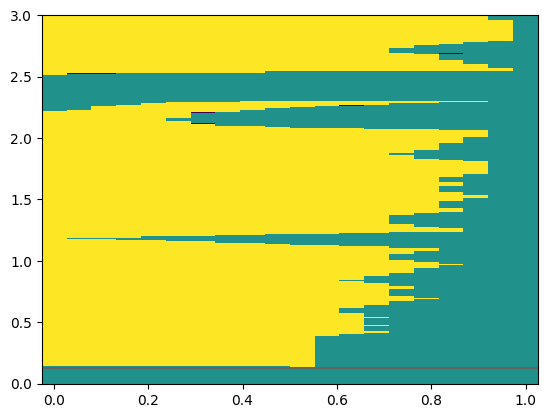

In [76]:
plt.pcolormesh(gamma_vector, T_vector, feasibility_matrix)
plt.axhline(np.pi/np.abs(np.imag(s0)), color="red", alpha=0.3)

In [68]:
for i in range(N_T):
    for j in range(N_gamma):
        print(f"{T_vector[i]=}, {gamma_vector[j]=}")
        prob = create_problem(T_vector[i], gamma_vector[j], s0, N, strategy="cheb")
        try:
            prob.solve()
        except Exception as e:
            print(e)
            feasibility_matrix[i,j] = -1
        if prob.status == "infeasible":
            print(prob.status)
            feasibility_matrix[i,j] = 0

T_vector[i]=0.0, gamma_vector[j]=0.001
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.053526315789473686
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.10605263157894737
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.15857894736842104
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.21110526315789474
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.26363157894736844
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3161578947368421
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3686842105263158
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4212105263157895
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4737368421052632
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5262631578947369
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5787894736842105
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6313157894736842
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6838421052631579
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7363684210526316
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7888947368421053
infeasible

c:\Users\peichl\source\tdspy\.venv\Lib\site-packages\cvxpy\problems\problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


T_vector[i]=0.888888888888889, gamma_vector[j]=0.10605263157894737
T_vector[i]=0.888888888888889, gamma_vector[j]=0.15857894736842104
T_vector[i]=0.888888888888889, gamma_vector[j]=0.21110526315789474
T_vector[i]=0.888888888888889, gamma_vector[j]=0.26363157894736844
T_vector[i]=0.888888888888889, gamma_vector[j]=0.3161578947368421
T_vector[i]=0.888888888888889, gamma_vector[j]=0.3686842105263158
T_vector[i]=0.888888888888889, gamma_vector[j]=0.4212105263157895
T_vector[i]=0.888888888888889, gamma_vector[j]=0.4737368421052632
T_vector[i]=0.888888888888889, gamma_vector[j]=0.5262631578947369
infeasible
T_vector[i]=0.888888888888889, gamma_vector[j]=0.5787894736842105
infeasible
T_vector[i]=0.888888888888889, gamma_vector[j]=0.6313157894736842
infeasible
T_vector[i]=0.888888888888889, gamma_vector[j]=0.6838421052631579
infeasible
T_vector[i]=0.888888888888889, gamma_vector[j]=0.7363684210526316
infeasible
T_vector[i]=0.888888888888889, gamma_vector[j]=0.7888947368421053
infeasible
T_vect

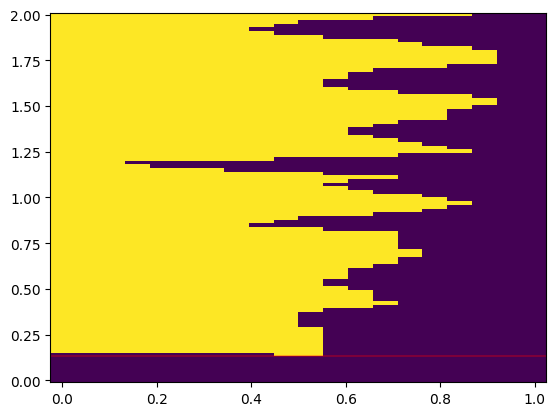

In [69]:
plt.pcolormesh(gamma_vector, T_vector, feasibility_matrix)
plt.axhline(np.pi/np.abs(np.imag(s0)), color="red", alpha=0.3)